<a href="https://colab.research.google.com/github/nharri64/ECGR-4105/blob/main/Noah_Harris_801353171_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from google.colab import files

uploaded = files.upload()

Saving D3.csv to D3 (1).csv


In [5]:
data = pd.read_csv('D3.csv')

data.head()

,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375


**Problem 1**

In [6]:
x1 = data['X1'].values
x2 = data['X2'].values
x3 = data['X3'].values
y = data['Y'].values

In [7]:
def gradient_descent_single(x, y, learning_rate, iterations):

    m = len(y)

    theta0 = 0.0
    theta1 = 0.0

    loss_history = []

    for i in range(iterations):

        # Calculate predictions
        y_pred = theta0 + theta1 * x

        # Calculate prediction error
        error = y_pred - y

        # Calculate cost
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        loss_history.append(loss)

        # Calculate gradients
        theta0_gradient = (1 / m) * np.sum(error)
        theta1_gradient = (1 / m) * np.sum(error * x)

        # Update theta values
        theta0 = theta0 - learning_rate * theta0_gradient
        theta1 = theta1 - learning_rate * theta1_gradient

    return theta0, theta1, loss_history

In [8]:
theta0_x1, theta1_x1, loss_x1 = gradient_descent_single(
    x1,
    y,
    learning_rate=0.1,
    iterations=1000
)

print("X1 Model")
print("Theta 0 =", theta0_x1)
print("Theta 1 =", theta1_x1)
print("Final Loss =", loss_x1[-1])

X1 Model
Theta 0 = 5.9279489169790756
Theta 1 = -2.038336633229477
Final Loss = 0.9849930825405946


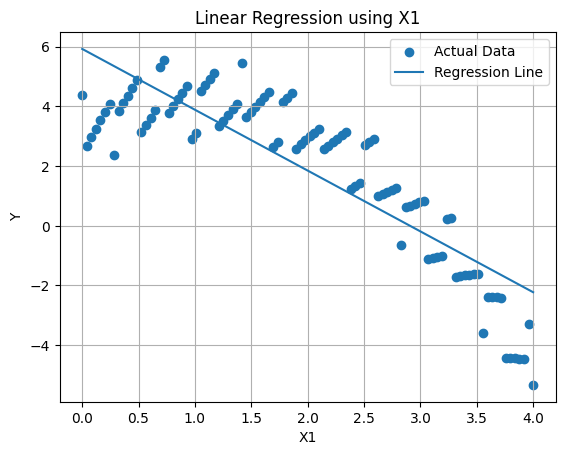

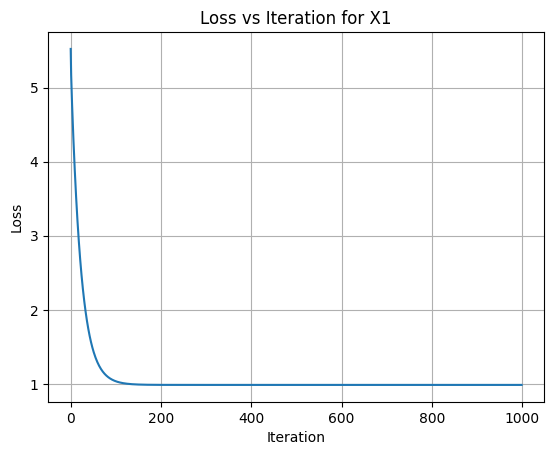

In [15]:
plt.scatter(x1, y, label='Actual Data')

y_pred_x1 = theta0_x1 + theta1_x1 * x1

plt.plot(x1, y_pred_x1, label='Regression Line')

plt.xlabel('X1')
plt.ylabel('Y')
plt.title('Linear Regression using X1')
plt.legend()
plt.grid()

plt.show()
plt.plot(loss_x1)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs Iteration for X1')
plt.grid()

plt.show()

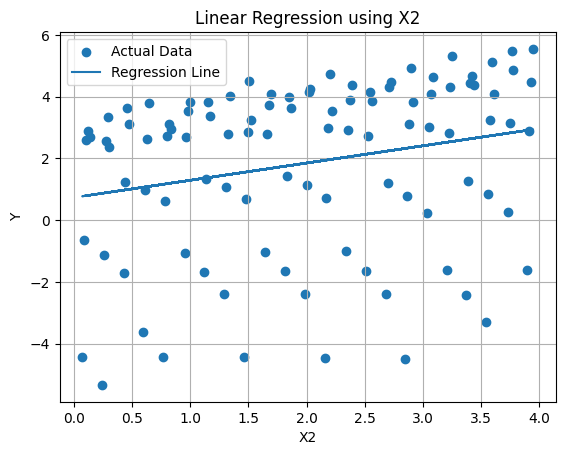

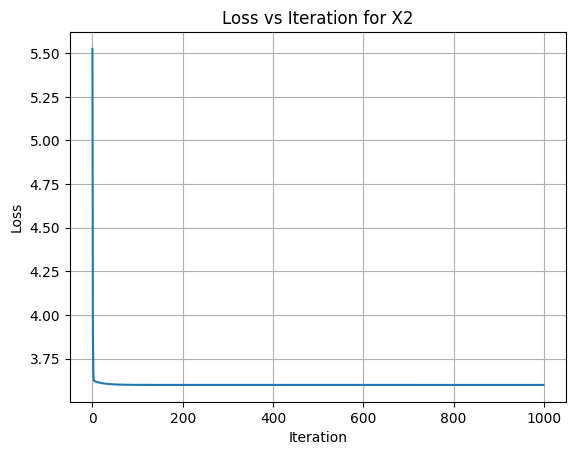

In [11]:
plt.scatter(x2, y, label='Actual Data')

y_pred_x2 = theta0_x2 + theta1_x2 * x2

plt.plot(x2, y_pred_x2, label='Regression Line')

plt.xlabel('X2')
plt.ylabel('Y')
plt.title('Linear Regression using X2')
plt.legend()
plt.grid()

plt.show()
plt.plot(loss_x2)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs Iteration for X2')
plt.grid()

plt.show()

In [13]:
theta0_x3, theta1_x3, loss_x3 = gradient_descent_single(
    x3,
    y,
    learning_rate=0.1,
    iterations=1000
)

print("X3 Model")
print("Theta 0 =", theta0_x3)
print("Theta 1 =", theta1_x3)
print("Final Loss =", loss_x3[-1])

X3 Model
Theta 0 = 2.8714221036339524
Theta 1 = -0.5204828841600003
Final Loss = 3.6294511246079155


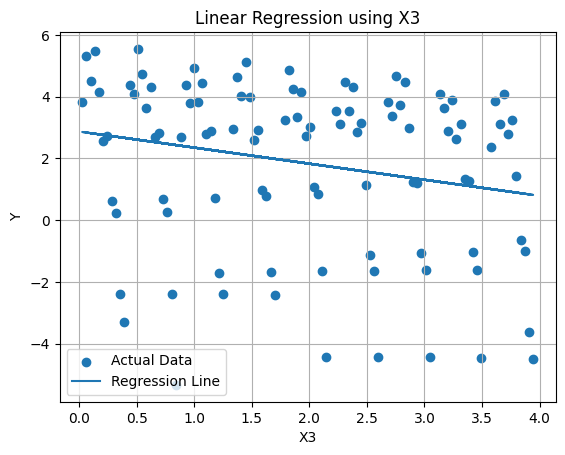

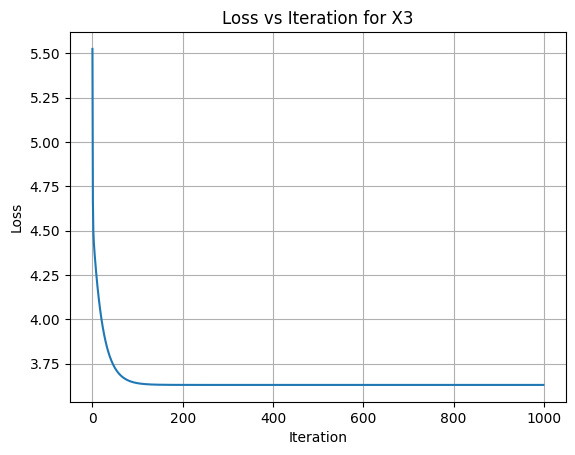

In [14]:
plt.scatter(x3, y, label='Actual Data')

y_pred_x3 = theta0_x3 + theta1_x3 * x3

plt.plot(x3, y_pred_x3, label='Regression Line')

plt.xlabel('X3')
plt.ylabel('Y')
plt.title('Linear Regression using X3')
plt.legend()
plt.grid()

plt.show()
plt.plot(loss_x3)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs Iteration for X3')
plt.grid()

plt.show()

Learning Rate: 0.01
Theta 0: 5.2929472827573
Theta 1: -1.791190790033247
Final Loss: 1.0366648249472639

Learning Rate: 0.05
Theta 0: 5.927864277730485
Theta 1: -2.0383036912064445
Final Loss: 0.9849930834751573

Learning Rate: 0.1
Theta 0: 5.9279489169790756
Theta 1: -2.038336633229477
Final Loss: 0.9849930825405946



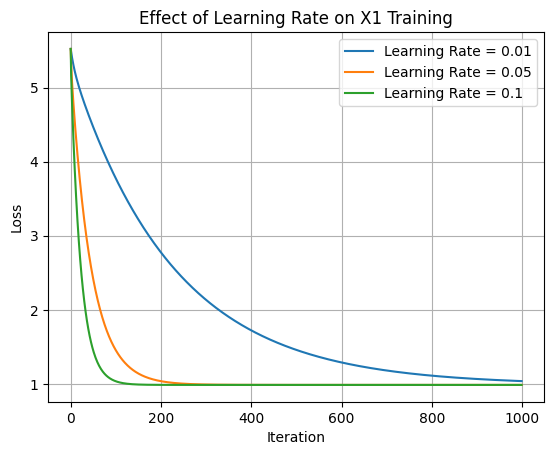

In [16]:
learning_rates = [0.01, 0.05, 0.1]

for lr in learning_rates:

    theta0, theta1, losses = gradient_descent_single(
        x1,
        y,
        learning_rate=lr,
        iterations=1000
    )

    print("Learning Rate:", lr)
    print("Theta 0:", theta0)
    print("Theta 1:", theta1)
    print("Final Loss:", losses[-1])
    print()
    learning_rates = [0.01, 0.05, 0.1]

for lr in learning_rates:

    theta0, theta1, losses = gradient_descent_single(
        x1,
        y,
        learning_rate=lr,
        iterations=1000
    )

    plt.plot(losses, label=f'Learning Rate = {lr}')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Effect of Learning Rate on X1 Training')
plt.legend()
plt.grid()

plt.show()

**Problem 2**

In [17]:
X = data[['X1', 'X2', 'X3']].values

In [18]:
def gradient_descent_multiple(X, y, learning_rate, iterations):

    m = len(y)

    # Add a column of ones for theta0
    X_with_bias = np.column_stack((np.ones(m), X))

    # Initialize all theta values to zero
    theta = np.zeros(X_with_bias.shape[1])

    loss_history = []

    for i in range(iterations):

        # Predictions
        y_pred = X_with_bias @ theta

        # Error
        error = y_pred - y

        # Cost
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        loss_history.append(loss)

        # Gradient
        gradient = (1 / m) * (X_with_bias.T @ error)

        # Update theta
        theta = theta - learning_rate * gradient

    return theta, loss_history

In [19]:
theta, loss_multiple = gradient_descent_multiple(
    X,
    y,
    learning_rate=0.1,
    iterations=1000
)

print("Theta values:", theta)
print("Final Loss:", loss_multiple[-1])

Theta values: [ 5.31393577 -2.00368658  0.53260157 -0.26556795]
Final Loss: 0.7384642444783827


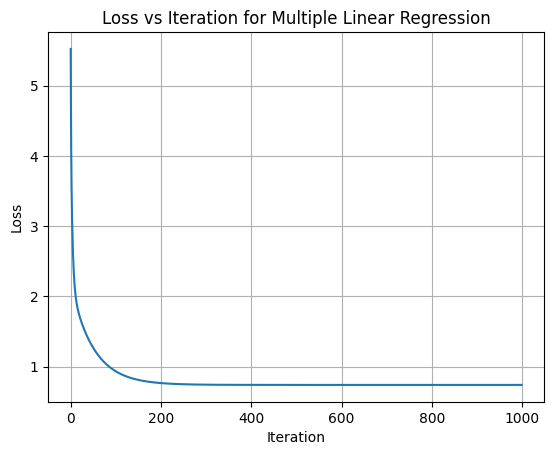

In [20]:
plt.plot(loss_multiple)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs Iteration for Multiple Linear Regression')
plt.grid()

plt.show()

In [22]:
learning_rates = [0.01, 0.05, 0.1]

for lr in learning_rates:

    theta_temp, losses_temp = gradient_descent_multiple(
        X,
        y,
        learning_rate=lr,
        iterations=1000
    )

    print("Learning Rate:", lr)
    print("Theta:", theta_temp)
    print("Final Loss:", losses_temp[-1])
    print()


Learning Rate: 0.01
Theta: [ 3.39929705 -1.73320582  0.84898275  0.0150737 ]
Final Loss: 0.9341735848306765

Learning Rate: 0.05
Theta: [ 5.27907019 -1.99876124  0.53836289 -0.26045736]
Final Loss: 0.7385305160274881

Learning Rate: 0.1
Theta: [ 5.31393577 -2.00368658  0.53260157 -0.26556795]
Final Loss: 0.7384642444783827



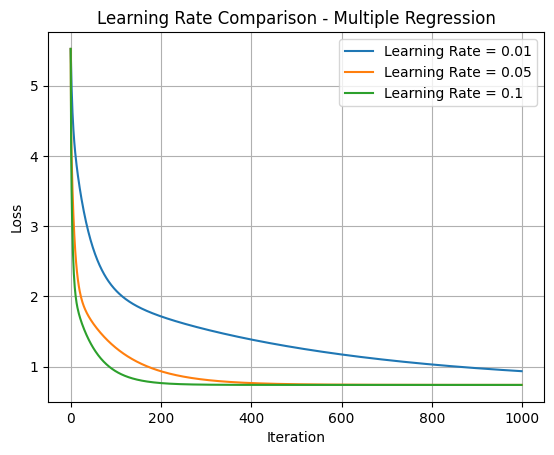

In [25]:
for lr in learning_rates:

    theta_temp, losses_temp = gradient_descent_multiple(
        X,
        y,
        learning_rate=lr,
        iterations=1000
    )

    plt.plot(losses_temp, label=f'Learning Rate = {lr}')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Learning Rate Comparison - Multiple Regression')
plt.legend()
plt.grid()

plt.show()

In [24]:
def predict(theta, x1, x2, x3):

    return (
        theta[0]
        + theta[1] * x1
        + theta[2] * x2
        + theta[3] * x3
    )


prediction1 = predict(theta, 1, 1, 1)
prediction2 = predict(theta, 2, 0, 4)
prediction3 = predict(theta, 3, 2, 1)

print("Prediction for (1,1,1):", prediction1)
print("Prediction for (2,0,4):", prediction2)
print("Prediction for (3,2,1):", prediction3)

Prediction for (1,1,1): 3.5772828177319926
Prediction for (2,0,4): 0.24429082475948705
Prediction for (3,2,1): 0.10251123321230132
